In [1]:
import sys
import git
import pathlib

# Set up the PROJ_ROOT variable
PROJ_ROOT_PATH = pathlib.Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
PROJ_ROOT =  str(PROJ_ROOT_PATH)
if PROJ_ROOT not in sys.path:
    sys.path.append(PROJ_ROOT)

# Explicitly add the current notebook's directory
CURRENT_DIR = str(pathlib.Path().absolute())
if CURRENT_DIR not in sys.path:
    sys.path.insert(0, CURRENT_DIR)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline  

In [3]:
# Load dataframe
exp = "ff-fc-delft-hemt-lp_mn-kide-pd_4K"
fname = PROJ_ROOT_PATH / "notebooks" / "experiments" / "pd" / exp / f"{exp}.pkl"
df =  pd.read_pickle(fname)

In [4]:
# Get 4K stage values
df_4K = df.loc["4K"]
# Sum all loads except amplifier loads
df_4K_no_amp = df_4K[df_4K.index.get_level_values(0) != "AMP_BIAS"]
no_amp_load = df_4K_no_amp.sum() # Passive and active loads from all other components

In [11]:
amp_configs = [(0.1,3E-3), #(Volt, Ampere)
               (0.3,6E-3),
               (0.5,8E-3),
               (0.6,13E-3),
               (1.0,20E-3)
              ]
total_no_of_qubits = 10_000
qubit_per_group = 8
cooling_pwr_4K = 6
num_of_groups = total_no_of_qubits/qubit_per_group

In [12]:
from library.cables import PHL_Mn_4K
from library.constants import R_Manganin

In [13]:
active_loads = []
ohmic_loads = []

for (voltage ,current) in amp_configs:
    active_load = voltage * current * num_of_groups/cooling_pwr_4K
    active_loads.append(active_load)
    
    # 2 -> two amplifilers per group
    # 2 -> Vd and GND cable
    # 0.5 -> half the heat flows to 50K stage
    ohmic_load = 2 * 2 * 0.5 * current **2 * R_Manganin * num_of_groups/cooling_pwr_4K
    ohmic_loads.append(ohmic_load)

# 2 -> two amplifilers per group
# 3 -> 3 wires per amplifier
passive_load = 2 * 3 * PHL_Mn_4K * num_of_groups/cooling_pwr_4K

passive_loads = [passive_load] * len(active_loads)
other_loads = [no_amp_load]* len(active_loads)
currents = [current for _, current in amp_configs]

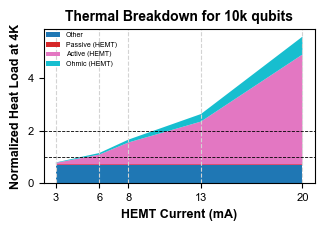

In [51]:
from library.utils import fontstyle, style_map

title_font, axis_label_font, tick_label_font, legend_font, text_font = fontstyle
# IEEE TQE Guidelines
# Single column: 3.5" (wide) x 8.5" (height)
# Double column: 7.16" (wide) x 8.5" (height)
fig, ax = plt.subplots(figsize=(3.5, 2.0))

import matplotlib.cm as cm
cmap = cm.tab10
# Generate colors from the colormap
colors = [cmap(i) for i in np.linspace(0, 1, 4)] # 4 colors for 4 layers

ax.stackplot(currents, other_loads, passive_loads, active_loads, ohmic_loads, labels=['Other', 'Passive (HEMT)', 'Active (HEMT)', 'Ohmic (HEMT)'], colors=colors)
# ax.stackplot(currents, other_loads, passive_loads, active_loads, ohmic_loads, labels=['Other', 'Passive (HEMT)', 'Active (HEMT)', 'Ohmic (HEMT)'], colors='Set3')

title = "Thermal Breakdown for 10k qubits"
ax.set_title(title, fontproperties=title_font)
ax.set_xlabel("HEMT Current (mA)", fontproperties=axis_label_font)
ax.set_ylabel("Normalized Heat Load at 4K", fontproperties=axis_label_font)
for label in ax.get_yticklabels() :
    label.set_fontproperties(tick_label_font)


ax.set_xticks(currents)
xticklabels = [f"{int(current*1E3)}" for current in currents]
ax.set_xticklabels(xticklabels, fontproperties=tick_label_font, rotation=0)

# Draw horizantal line at y=1
ax.axhline(y=1, color='k', linestyle='--',linewidth=0.6) # 10k qubits
ax.axhline(y=2, color='k', linestyle='--',linewidth=0.6) # 5k qubits

# Draw legend
ax.legend(ncol=1, 
          bbox_to_anchor=(0,1),
          loc='upper left',
          prop=legend_font,
          frameon=False,
          borderaxespad=0.)

# Draw grid
ax.grid(axis='x', color='lightgray', linestyle='--')

# Save figure
plt.savefig(f"./hemt_scalability.png",dpi=600)